# Multiple Regression, Polynomial Regression, Overfitting & Regularization
### Same weight-based story as the board, now hands-on

**Datasets (provided separately):**
- `multi_feature_delivery.csv` — 5000 rows: `distance_km`, `traffic_level`, `prep_time_min` -> `delivery_time_min`
- `curved_delivery.csv` — 2000 rows: `distance_km` -> `delivery_time_min` (curved relationship)

Add both as Kaggle inputs (or upload directly) before running.

In [1]:
import os
dataset_paths = {}
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if 'multi_feature' in filename:
            dataset_paths['multi'] = full_path
        elif 'curved' in filename:
            dataset_paths['curved'] = full_path
# If nothing printed: click 'Add Input' and attach both CSVs first
# (or, outside Kaggle: dataset_paths = {'multi': 'multi_feature_delivery.csv', 'curved': 'curved_delivery.csv'})

/kaggle/input/datasets/harsha050406/dataset-poly-and-multi/multi_feature_delivery.csv
/kaggle/input/datasets/harsha050406/dataset-poly-and-multi/curved_delivery.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

---
# Part 1 — Multiple Linear Regression

## 1.1 Load and check the data

In [3]:
assert 'multi' in dataset_paths, "Attach multi_feature_delivery.csv via Add Input first."
df_multi = pd.read_csv(dataset_paths['multi'])
df_multi.head()

,distance_km,traffic_level,prep_time_min,delivery_time_min
0,3.60,1,8.5,25.5
1,2.90,1,12.9,32.2
2,4.84,3,9.5,38.9
3,8.57,2,12.9,52.2
4,6.85,1,14.8,46.7


In [4]:
df_multi.isnull().sum()   # quick preprocessing check, same habit as always

distance_km          0
traffic_level        0
prep_time_min        0
delivery_time_min    0
dtype: int64

## 1.2 Train/test split with THREE features this time

In [5]:
feature_cols = ['distance_km', 'traffic_level', 'prep_time_min']
X = df_multi[feature_cols].values   # now a matrix with 3 columns, not just 1
y = df_multi['delivery_time_min'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training rows:', X_train.shape[0], '| Features per row:', X_train.shape[1])

Training rows: 4000 | Features per row: 3


## 1.3 Fit the model — same `.fit()` as before, just more columns

In [6]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)   # finds w1, w2, w3, and b together

for name, weight in zip(feature_cols, model_multi.coef_):
    print(f'w for {name}: {weight:.3f}')
print(f'bias (b): {model_multi.intercept_:.3f}')

w for distance_km: 3.221
w for traffic_level: 4.878
w for prep_time_min: 0.892
bias (b): 6.211


## 1.4 What each weight means — holding the others constant

This is today's central idea: each weight tells you the effect of ONE feature, with every other feature held fixed.

In [7]:
w_distance, w_traffic, w_prep = model_multi.coef_
print(f'Holding traffic and prep time fixed, each extra km adds about {w_distance:.2f} minutes.')
print(f'Holding distance and prep time fixed, each extra traffic level adds about {w_traffic:.2f} minutes.')
print(f'Holding distance and traffic fixed, each extra minute of prep adds about {w_prep:.2f} minutes.')

Holding traffic and prep time fixed, each extra km adds about 3.22 minutes.
Holding distance and prep time fixed, each extra traffic level adds about 4.88 minutes.
Holding distance and traffic fixed, each extra minute of prep adds about 0.89 minutes.


In [8]:
y_pred_multi = model_multi.predict(X_test)   # test on rows the model never trained on

mae = mean_absolute_error(y_test, y_pred_multi)
r2 = r2_score(y_test, y_pred_multi)
print(f'MAE: {mae:.2f} minutes')
print(f'R2:  {r2:.3f}')

MAE: 2.86 minutes
R2:  0.908


---
# Part 2 — Polynomial Regression

## 2.1 Load the curved dataset and see why a straight line struggles

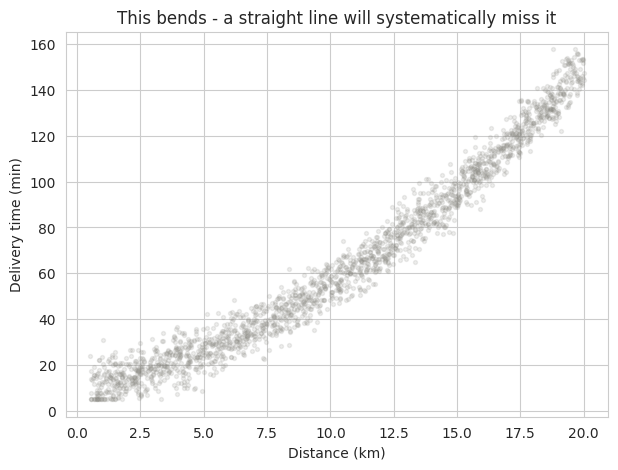

In [9]:
assert 'curved' in dataset_paths, "Attach curved_delivery.csv via Add Input first."
df_curved = pd.read_csv(dataset_paths['curved'])

plt.figure(figsize=(7,5))
plt.scatter(df_curved['distance_km'], df_curved['delivery_time_min'], alpha=0.15, s=8, color='#888780')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery time (min)')
plt.title('This bends - a straight line will systematically miss it')
plt.show()

## 2.2 The trick: turn x into x, x², x³... then it's linear regression again

`PolynomialFeatures` builds these extra columns for us — we don't compute powers by hand.

In [10]:
X_curved = df_curved[['distance_km']].values
y_curved = df_curved['delivery_time_min'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_curved, y_curved, test_size=0.2, random_state=42)

# Example: what PolynomialFeatures actually creates, for degree 3
poly_demo = PolynomialFeatures(degree=3, include_bias=False)
X_demo = poly_demo.fit_transform(X_train_c[:3])   # just the first 3 rows, to see the shape
print('Original x:\n', X_train_c[:3].flatten())
print('\nExpanded into [x, x^2, x^3]:\n', X_demo)

Original x:
 [ 2.51 18.17  8.6 ]

Expanded into [x, x^2, x^3]:
 [[2.51000000e+00 6.30010000e+00 1.58132510e+01]
 [1.81700000e+01 3.30148900e+02 5.99880551e+03]
 [8.60000000e+00 7.39600000e+01 6.36056000e+02]]


## 2.3 Fit degree 1, 3, and 15 — and compare train vs test error

This is the experiment behind the "underfitting vs overfitting" board diagram.

In [11]:
degrees = [1, 3, 15]
results = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_c)   # expand training x into powers
    X_test_poly = poly.transform(X_test_c)          # apply the SAME expansion to test x

    model = LinearRegression()
    model.fit(X_train_poly, y_train_c)               # ordinary linear regression on the expanded features

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_error = mean_squared_error(y_train_c, train_pred)
    test_error = mean_squared_error(y_test_c, test_pred)
    results.append((degree, train_error, test_error))
    print(f'Degree {degree:2d}  |  Train MSE: {train_error:8.2f}  |  Test MSE: {test_error:8.2f}')

Degree  1  |  Train MSE:    81.89  |  Test MSE:    85.67
Degree  3  |  Train MSE:    34.24  |  Test MSE:    31.89
Degree 15  |  Train MSE:    60.96  |  Test MSE:    55.07


## 2.4 Visualize all three fitted curves against the real data

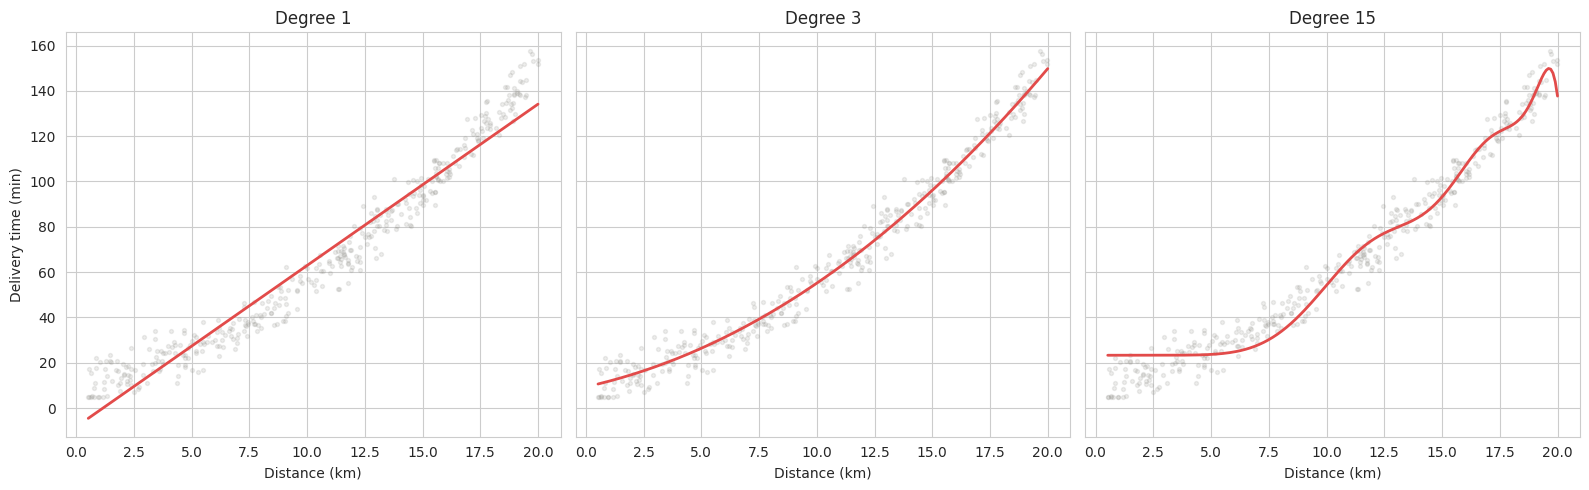

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
x_line = np.linspace(X_curved.min(), X_curved.max(), 200).reshape(-1, 1)

for ax, degree in zip(axes, degrees):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_c)
    model = LinearRegression()
    model.fit(X_train_poly, y_train_c)

    y_line = model.predict(poly.transform(x_line))   # predict along a smooth range of x for a clean curve

    ax.scatter(X_test_c, y_test_c, alpha=0.15, s=8, color='#888780')
    ax.plot(x_line, y_line, color='#E24B4A', linewidth=2)
    ax.set_title(f'Degree {degree}')
    ax.set_xlabel('Distance (km)')

axes[0].set_ylabel('Delivery time (min)')
plt.tight_layout()
plt.show()

## 2.5 The full degree sweep — train error vs test error

This reproduces the board's error-vs-degree chart, on our own data.

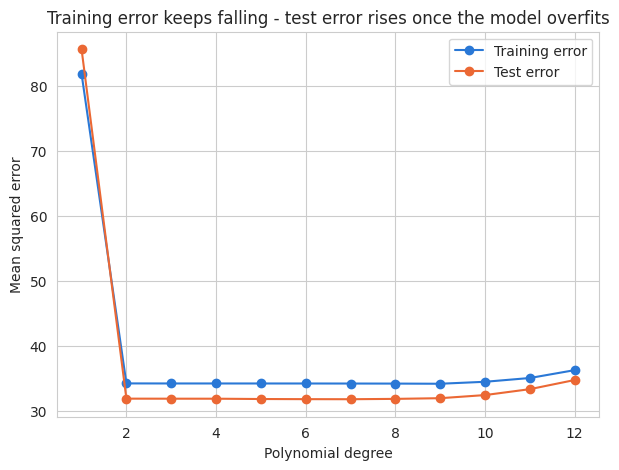

In [13]:
all_degrees = range(1, 13)
train_errors, test_errors = [], []

for degree in all_degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_c)
    X_test_poly = poly.transform(X_test_c)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_c)

    train_errors.append(mean_squared_error(y_train_c, model.predict(X_train_poly)))
    test_errors.append(mean_squared_error(y_test_c, model.predict(X_test_poly)))

plt.figure(figsize=(7,5))
plt.plot(list(all_degrees), train_errors, marker='o', color='#2a78d6', label='Training error')
plt.plot(list(all_degrees), test_errors, marker='o', color='#eb6834', label='Test error')
plt.xlabel('Polynomial degree')
plt.ylabel('Mean squared error')
plt.title('Training error keeps falling - test error rises once the model overfits')
plt.legend()
plt.show()

**Rule to remember: pick the degree with the lowest TEST error, not training error.**

---
# Part 3 — Regularization: Ridge vs Lasso

We go back to the multi-feature dataset for this, since regularization matters most when there are several features and some may be less useful than others.

## 3.1 Fit plain regression, Ridge, and Lasso side by side

In [14]:
model_plain = LinearRegression()
model_ridge = Ridge()   # default settings are fine for today - we're comparing the SHAPE of the effect, not tuning strength
model_lasso = Lasso()

model_plain.fit(X_train, y_train)
model_ridge.fit(X_train, y_train)
model_lasso.fit(X_train, y_train)

comparison = pd.DataFrame({
    'feature': feature_cols,
    'plain_weight': model_plain.coef_,
    'ridge_weight': model_ridge.coef_,
    'lasso_weight': model_lasso.coef_
})
comparison

,feature,plain_weight,ridge_weight,lasso_weight
0,distance_km,3.221481,3.221396,3.114890
1,traffic_level,4.877527,4.875369,3.101862
2,prep_time_min,0.891930,0.891907,0.818678


## 3.2 What changed?

Look for two things: are Ridge's weights generally SMALLER than plain regression's? Did Lasso push any weight to exactly 0?

In [15]:
for name, plain_w, ridge_w, lasso_w in zip(feature_cols, model_plain.coef_, model_ridge.coef_, model_lasso.coef_):
    zero_note = ' <- Lasso zeroed this out!' if abs(lasso_w) < 0.01 else ''
    print(f'{name:15s}  plain={plain_w:7.3f}  ridge={ridge_w:7.3f}  lasso={lasso_w:7.3f}{zero_note}')

distance_km      plain=  3.221  ridge=  3.221  lasso=  3.115
traffic_level    plain=  4.878  ridge=  4.875  lasso=  3.102
prep_time_min    plain=  0.892  ridge=  0.892  lasso=  0.819


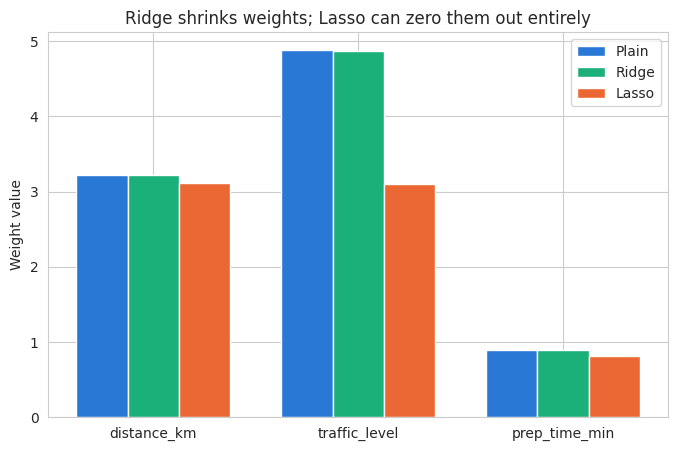

In [16]:
x_pos = np.arange(len(feature_cols))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x_pos - width, model_plain.coef_, width, label='Plain', color='#2a78d6')
plt.bar(x_pos, model_ridge.coef_, width, label='Ridge', color='#1baf7a')
plt.bar(x_pos + width, model_lasso.coef_, width, label='Lasso', color='#eb6834')
plt.xticks(x_pos, feature_cols)
plt.ylabel('Weight value')
plt.title('Ridge shrinks weights; Lasso can zero them out entirely')
plt.legend()
plt.show()

## 3.3 Does accuracy change much?

Since our 3 features are all genuinely useful here, don't expect a huge accuracy difference — regularization's benefit shows up most when some features are NOT useful.

In [17]:
for name, model in [('Plain', model_plain), ('Ridge', model_ridge), ('Lasso', model_lasso)]:
    pred = model.predict(X_test)
    print(f'{name:6s}  MAE: {mean_absolute_error(y_test, pred):.2f}  |  R2: {r2_score(y_test, pred):.3f}')

Plain   MAE: 2.86  |  R2: 0.908
Ridge   MAE: 2.86  |  R2: 0.908
Lasso   MAE: 3.02  |  R2: 0.895


## Recap
- Multiple regression: `ŷ = w1x1 + w2x2 + w3x3 + b` — each weight means "effect of this feature, holding the others constant"
- Multiple regression (different features) vs polynomial regression (powers of the SAME feature) — different problems, same underlying tool
- Polynomial regression is linear regression on expanded [x, x², x³...] columns
- Degree = model complexity: too low underfits, too high overfits (memorizes training data)
- Rule: pick the degree with the lowest TEST error, not training error
- Ridge shrinks all weights; Lasso can shrink some weights to exactly zero (built-in feature selection)

---

## Assignment
1. Write in a markdown cell what each of your multiple regression's 3 weights means in plain English (holding the other 2 features constant).
2. From your degree sweep chart, identify which degree looks like the best generalizing choice, and explain why in a markdown cell.
3. State which features (if any) Lasso zeroed out in your run, and what that implies about that feature's usefulness.

### Research task (for next class)
Read briefly about what "alpha" controls in Ridge/Lasso, and what cross-validation is for — one sentence each, ready to discuss next class.
